# Training Binary Classification Models on Processed Collections

This notebook trains 3610 logistic regression models for each collection in `processed_collections`:
- Collections: **naive**, **pairwise_rag_judge**, **pairwise_zeroshot_judge**, **voting_naive** → Logistic Regression

Models are trained with different features and saved weights as tensors.

In [1]:
import polars as pl
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import gc
import torch
import os
import json
from pathlib import Path
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score
from tqdm import tqdm
from utils.set_random_seed import set_random_seed

# Set random seed for reproducibility
set_random_seed(42)

# Configuration
BASE_PATH = Path(".")
COLLECTION_FOLDERS = ["llama_8b_instruction", "llama_8b_extraction"]
# MODEL_SUBFOLDERS = ["naive", "pairwise_rag_judge", "pairwise_zeroshot_judge", "voting_naive"]
MODEL_SUBFOLDERS = ["naive","voting_naive"]

print(f"Model folders to process: {COLLECTION_FOLDERS}")
print(f"Collection subfolders: {MODEL_SUBFOLDERS}")
print(f"Total collections per folder: {len(MODEL_SUBFOLDERS)}")

# Storage for results from all folders
all_results_by_folder = {}

Model folders to process: ['llama_8b_instruction', 'llama_8b_extraction']
Collection subfolders: ['naive', 'voting_naive']
Total collections per folder: 2


## Utility Functions

All helper functions for loading data, training models, saving weights, and evaluation.

**Organized into 5 subsections:**
1. **Data Loading** - Load feather files from processed_collections
2. **Model Training** - Train 3,610 logistic regression models per collection
3. **Saving Weights** - Persist weights/biases as PyTorch tensors
4. **Evaluation** - Compute performance statistics (mean, std, min, max)
5. **Visualization** - Plot performance distributions for each folder

In [2]:
# ============ DATA LOADING ============

def _filter_valid_evaluation_rows(df):
    """Drop rows with null/NaN evaluation values."""
    if "evaluation" not in df.columns:
        return df

    eval_dtype = df.schema.get("evaluation")
    valid_expr = pl.col("evaluation").is_not_null()
    if eval_dtype in (pl.Float32, pl.Float64):
        valid_expr = valid_expr & (~pl.col("evaluation").is_nan())

    return df.filter(valid_expr)

def load_collection_data(collection_name, processed_collections_path, split="train"):
    """Load a collection's data from feather files."""
    file_path = processed_collections_path / collection_name / f"{split}.feather"
    if not file_path.exists():
        print(f"Warning: {file_path} not found")
        return None
    return pl.read_ipc(str(file_path))

def load_collections_for_folder(folder_name, base_path=BASE_PATH):
    """Load all collections (subfolders) from a specific folder."""
    processed_collections_path = base_path / "processed_collections" / folder_name
    
    if not processed_collections_path.exists():
        print(f"Error: {processed_collections_path} does not exist")
        return None
    
    print(f"\n{'='*60}\nLoading collections from: {folder_name}\n{'='*60}")
    
    collections_data = {}
    for collection in MODEL_SUBFOLDERS:
        print(f"\nLoading {collection}...")
        collection_path = processed_collections_path / collection
        
        if collection_path.exists():
            train_df = load_collection_data(collection, processed_collections_path, "train")
            test_df = load_collection_data(collection, processed_collections_path, "test")
            
            if train_df is not None and test_df is not None:
                train_before = len(train_df)
                test_before = len(test_df)
                train_df = _filter_valid_evaluation_rows(train_df)
                test_df = _filter_valid_evaluation_rows(test_df)

                if "test_idx" in train_df.columns and "collection_idx" in train_df.columns:
                    train_df = train_df.sort("test_idx", "collection_idx")
                    test_df = test_df.sort("test_idx", "collection_idx")
                
                collections_data[collection] = {
                    "train": train_df,
                    "test": test_df,
                    "is_binary": True
                }
                print(
                    f"  Train shape: {train_df.shape}, Test shape: {test_df.shape} "
                    f"(filtered eval nulls: train {train_before-len(train_df)}, test {test_before-len(test_df)})"
                )
            else:
                print(f"  Failed to load {collection}")
        else:
            print(f"  Collection folder {collection} does not exist")
    
    return collections_data

In [3]:
# ============ MODEL TRAINING ============

def load_best_params(collection_name, collection_folder, processed_collections_path):
    """Load best hyperparameters from gridsearch JSON files. Returns None until tuning is available."""
    params_file = processed_collections_path.parent.parent / "hyperparameter_tuning" / collection_folder / f"best_params_gridsearch_{collection_name}.json"
    
    if not params_file.exists():
        print(f"Best params file not found for {collection_name} at {params_file}. Skipping hyperparameter tuning.")
        return None
    
    try:
        with open(params_file, "r") as f:
            data = json.load(f)
        best_params_list = [result.get("best_params") for result in data["results"]]
        print(f"Loaded best params for {collection_name} from {params_file}")
        return best_params_list
    except Exception as e:
        print(f"Error loading best params: {e}")
        return None

def _get_default_n_features(df):
    """Infer feature dimension from first non-empty input row."""
    probe = df.select("input").head(1).to_numpy()
    if len(probe) == 0:
        return 0
    return int(np.asarray(probe[0][0]).shape[0])

def _safe_n_features(x):
    """Return feature dimension safely for logging."""
    if isinstance(x, np.ndarray):
        if x.ndim == 2:
            return int(x.shape[1])
        if x.ndim == 1:
            return int(x.shape[0])
    return 0

def prepare_data_splits(df, num_models=3610):
    """Prepare data splits for training multiple models, dropping invalid labels per split."""
    X_splits, y_splits = [], []
    default_n_features = _get_default_n_features(df)
    
    for i in range(num_models):
        split_df = df.filter(pl.col("test_idx") == i)
        split_df = _filter_valid_evaluation_rows(split_df)

        if len(split_df) == 0:
            X_splits.append(np.empty((0, default_n_features), dtype=np.float32))
            y_splits.append(np.empty((0,), dtype=np.float32))
            continue

        X_raw = split_df.select("input").to_numpy()
        X = np.asarray([row[0] for row in X_raw], dtype=np.float32)
        if X.ndim == 1:
            X = X.reshape(1, -1)

        y = split_df.select("evaluation").to_numpy().ravel()

        X_splits.append(X)
        y_splits.append(y)
    
    return X_splits, y_splits

def train_collection_models(collection_name, collection_folder, collections_data, processed_collections_path, num_models=3610):
    """Train all models for a specific collection using LogisticRegression."""
    if collection_name not in collections_data.keys():
        print(f"Collection {collection_name} not loaded")
        return None
    
    train_df = collections_data[collection_name]["train"]
    test_df = collections_data[collection_name]["test"]
    
    print(f"\n{'='*60}\nTraining {num_models} models for {collection_name} (Binary Classification)\n{'='*60}")
    
    best_params_list = load_best_params(collection_name, collection_folder, processed_collections_path)
    X_train, y_train = prepare_data_splits(train_df, num_models)
    X_test, y_test = prepare_data_splits(test_df, num_models)
    
    models, evaluations, count_errors = [], [], 0
    
    with tqdm(total=num_models, desc=f"Training {collection_name}") as pbar:
        for i in range(num_models):
            model = None
            n_features = _safe_n_features(X_train[i])
            n_train_samples = len(X_train[i]) if hasattr(X_train[i], "__len__") else 0
            n_test_samples = len(X_test[i]) if hasattr(X_test[i], "__len__") else 0

            # Skip invalid train splits early
            if n_train_samples == 0 or n_features == 0 or len(np.unique(y_train[i])) < 2:
                count_errors += 1
                evaluations.append({
                    "model_idx": i, "score": None, "metric": "failed",
                    "n_features": n_features,
                    "n_train_samples": n_train_samples,
                    "n_test_samples": n_test_samples
                })
                models.append(None)
                pbar.update(1)
                continue
            
            if best_params_list and i < len(best_params_list) and best_params_list[i]:
                params = best_params_list[i].copy()
                if params.get("solver") in ["lbfgs", "newton-cg"]:
                    params.pop("l1_ratio", None)
                model = LogisticRegression(random_state=42, **params)
            else:
                model = LogisticRegression(max_iter=1000, random_state=42, solver='lbfgs')
            
            try:
                model.fit(X_train[i], y_train[i].ravel())
            except Exception:
                model = None
                count_errors += 1
            
            if model is not None:
                try:
                    y_pred_proba = model.predict_proba(X_test[i])[:, 1]
                    score = roc_auc_score(y_test[i].ravel(), y_pred_proba)
                    eval_metric = "auc"
                    
                    evaluations.append({
                        "model_idx": i, "score": score, "metric": eval_metric,
                        "n_features": n_features,
                        "n_train_samples": n_train_samples,
                        "n_test_samples": n_test_samples
                    })
                except Exception:
                    evaluations.append({
                        "model_idx": i, "score": None, "metric": "failed",
                        "n_features": n_features,
                        "n_train_samples": n_train_samples,
                        "n_test_samples": n_test_samples
                    })
            else:
                evaluations.append({
                    "model_idx": i, "score": None, "metric": "failed",
                    "n_features": n_features,
                    "n_train_samples": n_train_samples,
                    "n_test_samples": n_test_samples
                })
            
            models.append(model)
            pbar.update(1)
    
    print(f"  Total errors: {count_errors}/{num_models}")
    return {
        "models": models, "evaluations": evaluations, "is_binary": True,
        "collection_name": collection_name, "num_models": num_models
    }

def train_all_collections_in_folder(folder_name, collections_data, num_models=3610):
    """Train models for all collections in a folder."""
    processed_collections_path = BASE_PATH / "processed_collections" / folder_name
    trained_models = {}
    import warnings
    warnings.filterwarnings('ignore')
    
    for collection in MODEL_SUBFOLDERS:
        result = train_collection_models(collection, folder_name, collections_data, processed_collections_path, num_models)
        if result is not None:
            trained_models[collection] = result
        gc.collect()
    
    return trained_models

In [4]:
# ============ SAVING WEIGHTS ============

def save_model_weights(training_results, folder_name, base_path=BASE_PATH):
    """Save model weights and biases as PyTorch tensors to both weights/ and runs/ paths."""
    collection_name = training_results["collection_name"]
    models = training_results["models"]
    num_models = training_results["num_models"]
    
    weights_list, bias_list = [], []
    
    for model in models:
        if model is not None:
            weights_list.append(np.asarray(model.coef_[0], dtype=np.float32))
            bias_list.append(float(model.intercept_[0]))
        else:
            weights_list.append(np.concatenate([np.ones(16), np.zeros(84)]).astype(np.float32))
            bias_list.append(0.0)
    
    weights_tensor = torch.tensor(np.asarray(weights_list), dtype=torch.float32)
    bias_tensor = torch.tensor(bias_list, dtype=torch.float32)
    
    output_dir_pt = base_path / "weights" / folder_name / collection_name
    output_dir_pt.mkdir(parents=True, exist_ok=True)
    
    torch.save(weights_tensor, str(output_dir_pt / "weights.pt"))
    torch.save(bias_tensor, str(output_dir_pt / "bias.pt"))
    
    output_dir_runs = base_path / "runs" / folder_name / "datamodels" / "models" / collection_name
    output_dir_runs.mkdir(parents=True, exist_ok=True)
    
    weights_file_runs = output_dir_runs / f"0_{num_models-1}_weights.pt"
    bias_file_runs = output_dir_runs / f"0_{num_models-1}_bias.pt"
    
    torch.save(weights_tensor, str(weights_file_runs))
    torch.save(bias_tensor, str(bias_file_runs))
    
    print(f"\n  Saving {collection_name}: weights {weights_tensor.shape}, bias {bias_tensor.shape}")
    print(f"    Saved to: {output_dir_pt}")
    print(f"    Saved to: {output_dir_runs}")
    
    return {
        "weights_file_pt": str(output_dir_pt / "weights.pt"),
        "bias_file_pt": str(output_dir_pt / "bias.pt"),
        "weights_file_runs": str(weights_file_runs),
        "bias_file_runs": str(bias_file_runs),
        "weights_shape": weights_tensor.shape,
        "bias_shape": bias_tensor.shape
    }

def save_all_weights_for_folder(folder_name, trained_models, base_path=BASE_PATH):
    """Save weights for all collections in a folder."""
    return {collection_name: save_model_weights(training_results, folder_name, base_path)
            for collection_name, training_results in trained_models.items()}

In [5]:
# ============ EVALUATION ============

def _valid_score_frame(evaluations):
    """Return a DataFrame with only numeric, finite scores."""
    eval_df = pl.DataFrame(evaluations)
    if "score" not in eval_df.columns or len(eval_df) == 0:
        return pl.DataFrame(schema={"score": pl.Float64})

    score_series = eval_df["score"]
    if score_series.dtype == pl.Null:
        return pl.DataFrame(schema={"score": pl.Float64})

    return eval_df.filter(
        pl.col("score").is_not_null() &
        (~pl.col("score").is_nan() if score_series.dtype in (pl.Float32, pl.Float64) else pl.lit(True))
    )

def create_evaluation_summary(training_results, folder_name):
    """Create evaluation summary for a collection."""
    collection_name = training_results["collection_name"]
    evaluations = training_results["evaluations"]
    
    valid_scores = _valid_score_frame(evaluations)
    
    if len(valid_scores) > 0:
        return {
            "folder": folder_name, "collection": collection_name,
            "type": "Binary Classification",
            "metric": "auc",
            "num_models": int(len(evaluations)),
            "successful_models": int(len(valid_scores)),
            "mean_score": float(valid_scores.select(pl.col("score").mean())[0, 0]),
            "std_score": float(valid_scores.select(pl.col("score").std())[0, 0]),
            "min_score": float(valid_scores.select(pl.col("score").min())[0, 0]),
            "max_score": float(valid_scores.select(pl.col("score").max())[0, 0]),
        }
    else:
        return {
            "folder": folder_name, "collection": collection_name,
            "type": "Binary Classification",
            "metric": "N/A", "num_models": len(evaluations), "successful_models": 0,
            "mean_score": None, "std_score": None, "min_score": None, "max_score": None,
        }

def create_summaries_for_folder(folder_name, trained_models):
    """Generate evaluation summaries for all collections in a folder."""
    summaries = []
    print(f"\n{'='*60}\nEvaluation Summary for {folder_name}\n{'='*60}")
    
    for collection_name, training_results in trained_models.items():
        summary = create_evaluation_summary(training_results, folder_name)
        summaries.append(summary)
        print(f"\n{collection_name}:")
        for key, value in summary.items():
            if key not in ["folder", "collection", "type", "metric"] and isinstance(value, (int, float)):
                print(f"  {key}: {value:.4f}" if isinstance(value, float) else f"  {key}: {value}")
    
    return summaries

In [6]:
# ============ VISUALIZATION ============

def plot_folder_performance(folder_name, trained_models):
    """Create performance distribution plots for a folder."""
    collections_to_plot = [c for c in MODEL_SUBFOLDERS if c in trained_models]
    num_cols = len(collections_to_plot)
    
    fig, axes = plt.subplots(1, num_cols, figsize=(5*num_cols, 5))
    
    if num_cols == 1:
        axes = np.array([axes])
    
    color = "#87CEEB"
    
    for idx, collection_name in enumerate(collections_to_plot):
        valid_scores = _valid_score_frame(trained_models[collection_name]["evaluations"])
        
        if len(valid_scores) > 0:
            sns.histplot(data=valid_scores.select("score").to_pandas(), x="score", bins=30,
                        color=color, kde=True, ax=axes[idx],
                        stat="density", edgecolor='white', linewidth=0.5)
            axes[idx].set_title(f"{collection_name.replace('_', ' ').title()}", fontsize=11, fontweight='bold')
            axes[idx].set_xlabel("AUC Score", fontsize=10)
            axes[idx].set_ylabel("Density", fontsize=10)
            axes[idx].grid(axis='y', alpha=0.2, linestyle='--')
            axes[idx].set_axisbelow(True)
            axes[idx].set_facecolor('#fafafa')
            
            mean_score = valid_scores.select(pl.col("score").mean())[0, 0]
            std_score = valid_scores.select(pl.col("score").std())[0, 0]
            axes[idx].axvspan(mean_score - std_score, mean_score + std_score, 
                            color='darkblue', alpha=0.1, label=f'±1 Std Dev: ±{std_score:.3f}', zorder=5)
            axes[idx].axvline(mean_score, color='darkblue', linestyle='--', linewidth=2.5, alpha=0.8,
                            label=f'Mean: {mean_score:.3f}', zorder=10)
            axes[idx].legend(loc='upper right', fontsize=8, framealpha=0.95)
        else:
            axes[idx].axis('off')
    
    fig.suptitle(f'Model Performance Distribution - {folder_name.upper()}\n(3,610 models per collection)',
                 fontsize=14, fontweight='bold', y=0.98)
    
    plt.tight_layout()
    plt.show()
    plt.close()

In [7]:
# ============ SAVING RESULTS FOR AGGREGATION ============

def save_results_for_folder(folder_name, trained_models, summaries, base_path=BASE_PATH):
    """Save evaluation results to JSON for later aggregation."""
    results_dir = base_path / "aggregation_results"
    results_dir.mkdir(parents=True, exist_ok=True)
    
    results = {
        "folder": folder_name,
        "summaries": summaries,
        "evaluations": {}
    }
    
    for collection_name, training_results in trained_models.items():
        valid_scores = _valid_score_frame(training_results["evaluations"])
        
        if len(valid_scores) > 0:
            results["evaluations"][collection_name] = {
                "is_binary": training_results["is_binary"],
                "scores": valid_scores.select("score").to_numpy().flatten().tolist(),
                "mean": float(valid_scores.select(pl.col("score").mean())[0, 0]),
                "std": float(valid_scores.select(pl.col("score").std())[0, 0]),
                "min": float(valid_scores.select(pl.col("score").min())[0, 0]),
                "max": float(valid_scores.select(pl.col("score").max())[0, 0]),
            }
    
    results_file = results_dir / f"{folder_name}_results.json"
    with open(results_file, "w") as f:
        json.dump(results, f, indent=2)
    
    print(f"Saved results for {folder_name} to {results_file}")
    return results_file

def load_all_results(base_path=BASE_PATH):
    """Load all saved results from aggregation_results directory."""
    results_dir = base_path / "aggregation_results"
    all_results = {}
    
    if not results_dir.exists():
        print(f"Error: {results_dir} does not exist")
        return None
    
    for results_file in sorted(results_dir.glob("*_results.json")):
        with open(results_file, "r") as f:
            data = json.load(f)
            folder_name = data["folder"]
            all_results[folder_name] = data
    
    return all_results

## Full Processing: LLAMA, LLAMA_DEFAULT, QWEN, QWEN_DEFAULT

Load, train, save, and visualize results for each collection folder.

### Processing: LLAMA

Load, train, save, and visualize results for the llama collection folder.


Loading collections from: llama

Loading naive...


Could not memory_map compressed IPC file, defaulting to normal read. Toggle off 'memory_map' to silence this warning.
Could not memory_map compressed IPC file, defaulting to normal read. Toggle off 'memory_map' to silence this warning.


  Train shape: (6769385, 7), Test shape: (677659, 7) (filtered eval nulls: train 450615, test 44341)

Training 3610 models for naive (Binary Classification)
Loaded best params for naive from hyperparameter_tuning/llama/best_params_gridsearch_naive.json


Training naive: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████| 3610/3610 [04:35<00:00, 13.11it/s]


  Total errors: 0/3610

Saving weights for llama

  Saving naive: weights torch.Size([3610, 100]), bias torch.Size([3610])
    Saved to: weights/llama/naive
    Saved to: runs/llama/datamodels/models/naive

Evaluation Summary for llama

naive:
  num_models: 3610
  successful_models: 3607
  mean_score: 0.6082
  std_score: 0.0978
  min_score: 0.1640
  max_score: 0.9830
Saved results for llama to aggregation_results/llama_results.json


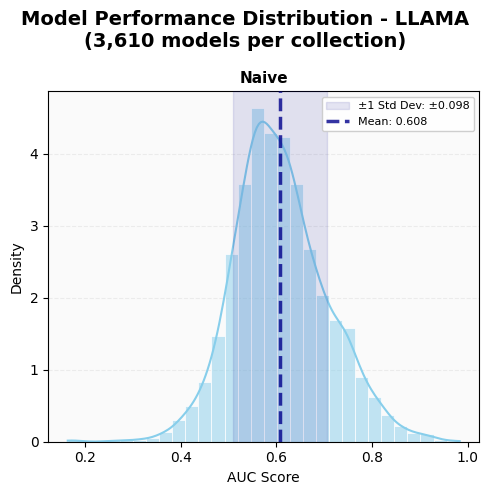


Completed processing llama


In [8]:
folder_name = "llama"

collections_data_llama = load_collections_for_folder(folder_name, BASE_PATH)

if collections_data_llama:
    trained_models_llama = train_all_collections_in_folder(folder_name, collections_data_llama, num_models=3610)
    print(f"\n{'='*60}\nSaving weights for {folder_name}\n{'='*60}")
    saved_weights_llama = save_all_weights_for_folder(folder_name, trained_models_llama, BASE_PATH)
    summaries_llama = create_summaries_for_folder(folder_name, trained_models_llama)
    save_results_for_folder(folder_name, trained_models_llama, summaries_llama, BASE_PATH)
    all_results_by_folder[folder_name] = {
        "collections_data": collections_data_llama,
        "trained_models": trained_models_llama,
        "saved_weights": saved_weights_llama,
        "summaries": summaries_llama
    }
    plot_folder_performance(folder_name, trained_models_llama)
    print(f"\nCompleted processing {folder_name}")
    gc.collect()
else:
    print(f"Failed to load collections for {folder_name}")

del collections_data_llama, trained_models_llama, saved_weights_llama, summaries_llama

### Processing: LLAMA_DEFAULT

Load, train, save, and visualize results for the llama_default collection folder.


Loading collections from: llama_default

Loading naive...


Could not memory_map compressed IPC file, defaulting to normal read. Toggle off 'memory_map' to silence this warning.
Could not memory_map compressed IPC file, defaulting to normal read. Toggle off 'memory_map' to silence this warning.


  Train shape: (5913335, 7), Test shape: (698417, 7) (filtered eval nulls: train 223665, test 23583)

Loading pairwise_rag_judge...


Could not memory_map compressed IPC file, defaulting to normal read. Toggle off 'memory_map' to silence this warning.
Could not memory_map compressed IPC file, defaulting to normal read. Toggle off 'memory_map' to silence this warning.


  Train shape: (7102306, 7), Test shape: (707504, 7) (filtered eval nulls: train 117694, test 14496)

Loading pairwise_zeroshot_judge...


...

  Total errors: 0/3610

Training 3610 models for pairwise_zeroshot_judge (Binary Classification)
Loaded best params for pairwise_zeroshot_judge from hyperparameter_tuning/llama_default/best_params_gridsearch_pairwise_zeroshot_judge.json


Training pairwise_zeroshot_judge: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████| 3610/3610 [02:28<00:00, 24.25it/s]


  Total errors: 0/3610

Training 3610 models for voting_naive (Binary Classification)
Loaded best params for voting_naive from hyperparameter_tuning/llama_default/best_params_gridsearch_voting_naive.json


Training voting_naive: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 3610/3610 [06:05<00:00,  9.87it/s]


  Total errors: 4/3610

Saving weights for llama_default

  Saving naive: weights torch.Size([3610, 100]), bias torch.Size([3610])
    Saved to: weights/llama_default/naive
    Saved to: runs/llama_default/datamodels/models/naive

  Saving pairwise_rag_judge: weights torch.Size([3610, 100]), bias torch.Size([3610])
    Saved to: weights/llama_default/pairwise_rag_judge
    Saved to: runs/llama_default/datamodels/models/pairwise_rag_judge

  Saving pairwise_zeroshot_judge: weights torch.Size([3610, 100]), bias torch.Size([3610])
    Saved to: weights/llama_default/pairwise_zeroshot_judge
    Saved to: runs/llama_default/datamodels/models/pairwise_zeroshot_judge

  Saving voting_naive: weights torch.Size([3610, 100]), bias torch.Size([3610])
    Saved to: weights/llama_default/voting_naive
    Saved to: runs/llama_default/datamodels/models/voting_naive

Evaluation Summary for llama_default

naive:
  num_models: 3610
  successful_models: 3605
  mean_score: 0.5820
  std_score: 0.0853
  min

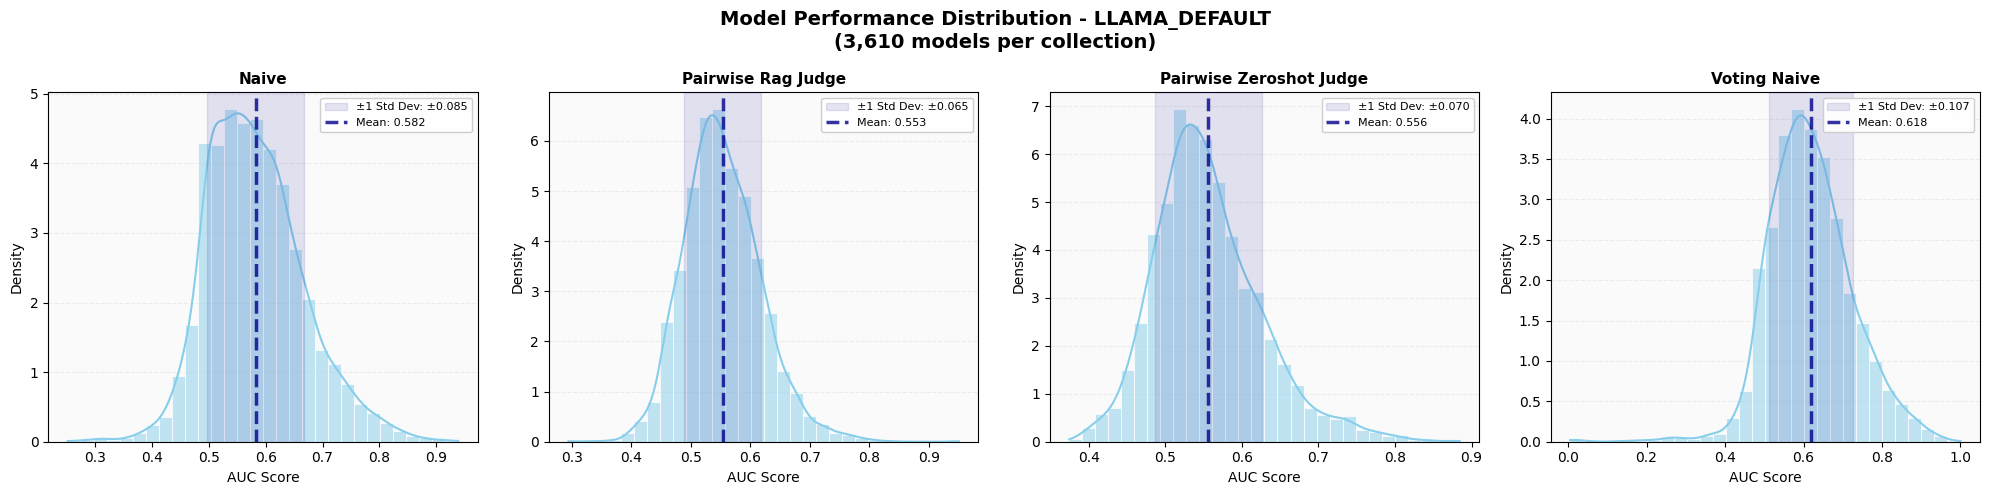


Completed processing llama_default


In [8]:
folder_name = "llama_default"

collections_data_llama_default = load_collections_for_folder(folder_name, BASE_PATH)

if collections_data_llama_default:
    trained_models_llama_default = train_all_collections_in_folder(folder_name, collections_data_llama_default, num_models=3610)
    print(f"\n{'='*60}\nSaving weights for {folder_name}\n{'='*60}")
    saved_weights_llama_default = save_all_weights_for_folder(folder_name, trained_models_llama_default, BASE_PATH)
    summaries_llama_default = create_summaries_for_folder(folder_name, trained_models_llama_default)
    save_results_for_folder(folder_name, trained_models_llama_default, summaries_llama_default, BASE_PATH)
    all_results_by_folder[folder_name] = {
        "collections_data": collections_data_llama_default,
        "trained_models": trained_models_llama_default,
        "saved_weights": saved_weights_llama_default,
        "summaries": summaries_llama_default
    }
    plot_folder_performance(folder_name, trained_models_llama_default)
    print(f"\nCompleted processing {folder_name}")
    gc.collect()
else:
    print(f"Failed to load collections for {folder_name}")

del collections_data_llama_default, trained_models_llama_default, saved_weights_llama_default, summaries_llama_default

### Processing: QWEN

Load, train, save, and visualize results for the qwen collection folder.


Loading collections from: qwen

Loading naive...


Could not memory_map compressed IPC file, defaulting to normal read. Toggle off 'memory_map' to silence this warning.
Could not memory_map compressed IPC file, defaulting to normal read. Toggle off 'memory_map' to silence this warning.


  Train shape: (7169124, 7), Test shape: (719029, 7) (filtered eval nulls: train 50876, test 2971)

Loading pairwise_rag_judge...


Could not memory_map compressed IPC file, defaulting to normal read. Toggle off 'memory_map' to silence this warning.
Could not memory_map compressed IPC file, defaulting to normal read. Toggle off 'memory_map' to silence this warning.


  Train shape: (6608167, 7), Test shape: (664226, 7) (filtered eval nulls: train 611833, test 57774)

Loading pairwise_zeroshot_judge...


...

  Total errors: 175/3610

Training 3610 models for pairwise_zeroshot_judge (Binary Classification)
Loaded best params for pairwise_zeroshot_judge from hyperparameter_tuning/qwen/best_params_gridsearch_pairwise_zeroshot_judge.json


Training pairwise_zeroshot_judge: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████| 3610/3610 [01:45<00:00, 34.18it/s]


  Total errors: 91/3610

Training 3610 models for voting_naive (Binary Classification)
Loaded best params for voting_naive from hyperparameter_tuning/qwen/best_params_gridsearch_voting_naive.json


Training voting_naive: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 3610/3610 [06:01<00:00,  9.99it/s]


  Total errors: 178/3610

Saving weights for qwen

  Saving naive: weights torch.Size([3610, 100]), bias torch.Size([3610])
    Saved to: weights/qwen/naive
    Saved to: runs/qwen/datamodels/models/naive

  Saving pairwise_rag_judge: weights torch.Size([3610, 100]), bias torch.Size([3610])
    Saved to: weights/qwen/pairwise_rag_judge
    Saved to: runs/qwen/datamodels/models/pairwise_rag_judge

  Saving pairwise_zeroshot_judge: weights torch.Size([3610, 100]), bias torch.Size([3610])
    Saved to: weights/qwen/pairwise_zeroshot_judge
    Saved to: runs/qwen/datamodels/models/pairwise_zeroshot_judge

  Saving voting_naive: weights torch.Size([3610, 100]), bias torch.Size([3610])
    Saved to: weights/qwen/voting_naive
    Saved to: runs/qwen/datamodels/models/voting_naive

Evaluation Summary for qwen

naive:
  num_models: 3610
  successful_models: 3373
  mean_score: 0.6284
  std_score: 0.1511
  min_score: 0.0000
  max_score: 1.0000

pairwise_rag_judge:
  num_models: 3610
  successful_

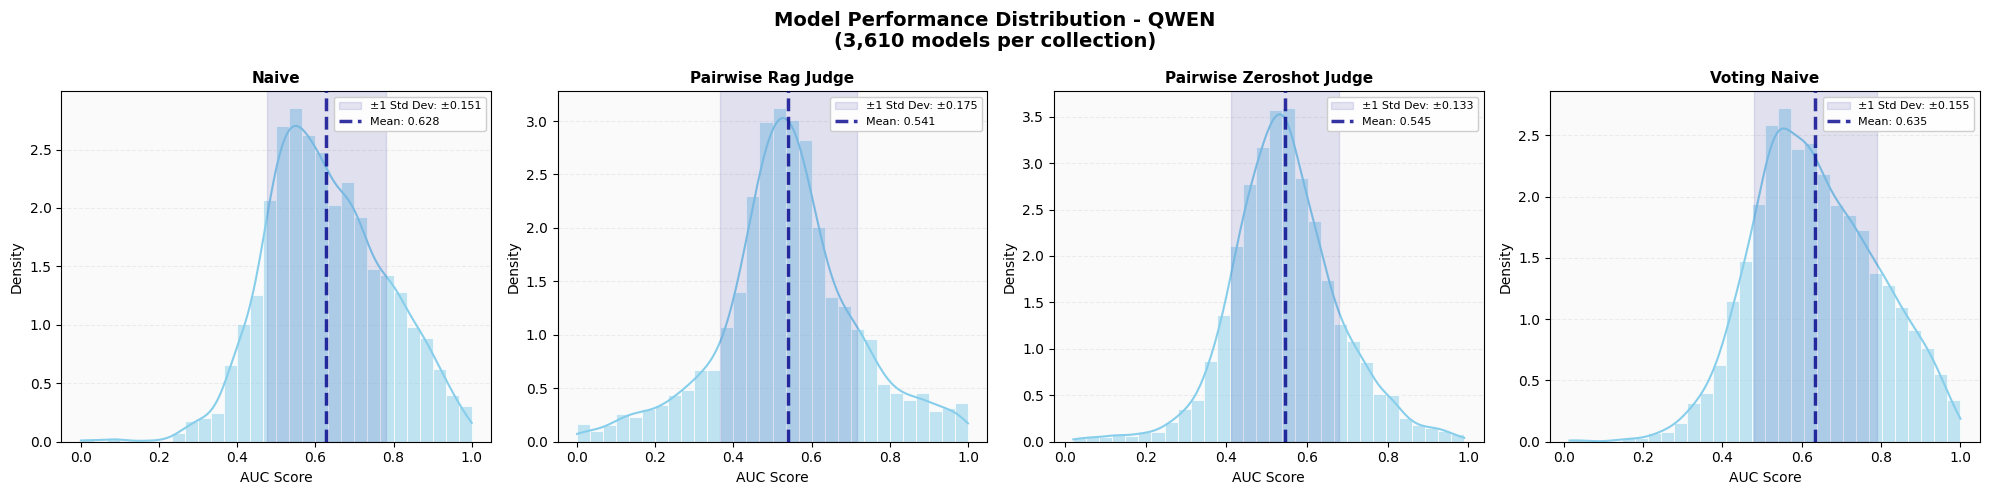


Completed processing qwen


In [8]:
folder_name = "qwen"

collections_data_qwen = load_collections_for_folder(folder_name, BASE_PATH)

if collections_data_qwen:
    trained_models_qwen = train_all_collections_in_folder(folder_name, collections_data_qwen, num_models=3610)
    print(f"\n{'='*60}\nSaving weights for {folder_name}\n{'='*60}")
    saved_weights_qwen = save_all_weights_for_folder(folder_name, trained_models_qwen, BASE_PATH)
    summaries_qwen = create_summaries_for_folder(folder_name, trained_models_qwen)
    save_results_for_folder(folder_name, trained_models_qwen, summaries_qwen, BASE_PATH)
    all_results_by_folder[folder_name] = {
        "collections_data": collections_data_qwen,
        "trained_models": trained_models_qwen,
        "saved_weights": saved_weights_qwen,
        "summaries": summaries_qwen
    }
    plot_folder_performance(folder_name, trained_models_qwen)
    print(f"\nCompleted processing {folder_name}")
    gc.collect()
else:
    print(f"Failed to load collections for {folder_name}")

del collections_data_qwen, trained_models_qwen, saved_weights_qwen, summaries_qwen

### Processing: QWEN_DEFAULT

Load, train, save, and visualize results for the qwen_default collection folder.


Loading collections from: qwen_default

Loading naive...


Could not memory_map compressed IPC file, defaulting to normal read. Toggle off 'memory_map' to silence this warning.
Could not memory_map compressed IPC file, defaulting to normal read. Toggle off 'memory_map' to silence this warning.


  Train shape: (7190643, 7), Test shape: (719140, 7) (filtered eval nulls: train 29357, test 2860)

Loading pairwise_rag_judge...


Could not memory_map compressed IPC file, defaulting to normal read. Toggle off 'memory_map' to silence this warning.
Could not memory_map compressed IPC file, defaulting to normal read. Toggle off 'memory_map' to silence this warning.


  Train shape: (7193597, 7), Test shape: (719410, 7) (filtered eval nulls: train 26403, test 2590)

Loading pairwise_zeroshot_judge...


...

  Total errors: 0/3610

Training 3610 models for pairwise_zeroshot_judge (Binary Classification)
Loaded best params for pairwise_zeroshot_judge from hyperparameter_tuning/qwen_default/best_params_gridsearch_pairwise_zeroshot_judge.json


Training pairwise_zeroshot_judge: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████| 3610/3610 [01:58<00:00, 30.37it/s]


  Total errors: 7/3610

Training 3610 models for voting_naive (Binary Classification)
Loaded best params for voting_naive from hyperparameter_tuning/qwen_default/best_params_gridsearch_voting_naive.json


Training voting_naive: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 3610/3610 [04:59<00:00, 12.06it/s]


  Total errors: 27/3610

Saving weights for qwen_default

  Saving naive: weights torch.Size([3610, 100]), bias torch.Size([3610])
    Saved to: weights/qwen_default/naive
    Saved to: runs/qwen_default/datamodels/models/naive

  Saving pairwise_rag_judge: weights torch.Size([3610, 100]), bias torch.Size([3610])
    Saved to: weights/qwen_default/pairwise_rag_judge
    Saved to: runs/qwen_default/datamodels/models/pairwise_rag_judge

  Saving pairwise_zeroshot_judge: weights torch.Size([3610, 100]), bias torch.Size([3610])
    Saved to: weights/qwen_default/pairwise_zeroshot_judge
    Saved to: runs/qwen_default/datamodels/models/pairwise_zeroshot_judge

  Saving voting_naive: weights torch.Size([3610, 100]), bias torch.Size([3610])
    Saved to: weights/qwen_default/voting_naive
    Saved to: runs/qwen_default/datamodels/models/voting_naive

Evaluation Summary for qwen_default

naive:
  num_models: 3610
  successful_models: 3524
  mean_score: 0.6885
  std_score: 0.1437
  min_score: 0

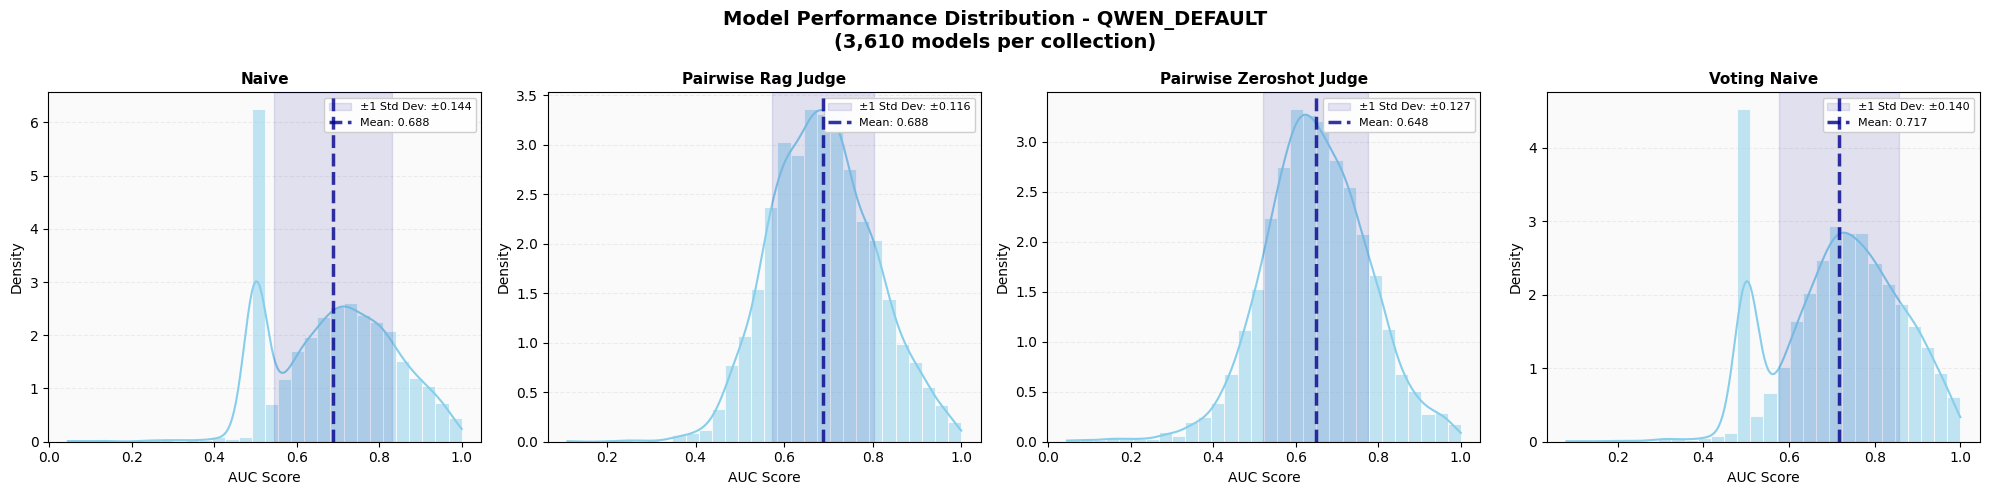


Completed processing qwen_default

COMPLETED: Processed 1 folders


In [8]:
folder_name = "qwen_default"

collections_data_qwen_default = load_collections_for_folder(folder_name, BASE_PATH)

if collections_data_qwen_default:
    trained_models_qwen_default = train_all_collections_in_folder(folder_name, collections_data_qwen_default, num_models=3610)
    print(f"\n{'='*60}\nSaving weights for {folder_name}\n{'='*60}")
    saved_weights_qwen_default = save_all_weights_for_folder(folder_name, trained_models_qwen_default, BASE_PATH)
    summaries_qwen_default = create_summaries_for_folder(folder_name, trained_models_qwen_default)
    save_results_for_folder(folder_name, trained_models_qwen_default, summaries_qwen_default, BASE_PATH)
    all_results_by_folder[folder_name] = {
        "collections_data": collections_data_qwen_default,
        "trained_models": trained_models_qwen_default,
        "saved_weights": saved_weights_qwen_default,
        "summaries": summaries_qwen_default
    }
    plot_folder_performance(folder_name, trained_models_qwen_default)
    print(f"\nCompleted processing {folder_name}")
    gc.collect()
else:
    print(f"Failed to load collections for {folder_name}")

print(f"\n{'='*70}\nCOMPLETED: Processed {len(all_results_by_folder)} folders\n{'='*70}")
del collections_data_qwen_default, trained_models_qwen_default, saved_weights_qwen_default, summaries_qwen_default

### Processing: Llama 8B Instruction

Load, train, save, and visualize results for the qwen_default collection folder.


Loading collections from: llama_8b_instruction

Loading naive...


Could not memory_map compressed IPC file, defaulting to normal read. Toggle off 'memory_map' to silence this warning.
Could not memory_map compressed IPC file, defaulting to normal read. Toggle off 'memory_map' to silence this warning.


  Train shape: (6691145, 7), Test shape: (669087, 7) (filtered eval nulls: train 528855, test 52913)

Loading voting_naive...


Could not memory_map compressed IPC file, defaulting to normal read. Toggle off 'memory_map' to silence this warning.
Could not memory_map compressed IPC file, defaulting to normal read. Toggle off 'memory_map' to silence this warning.


  Train shape: (6317500, 7), Test shape: (722000, 7) (filtered eval nulls: train 0, test 0)

Training 3610 models for naive (Binary Classification)
Best params file not found for naive at hyperparameter_tuning/llama_8b_instruction/best_params_gridsearch_naive.json. Skipping hyperparameter tuning.


Training naive: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 3610/3610 [00:54<00:00, 65.66it/s]


  Total errors: 27/3610

Training 3610 models for voting_naive (Binary Classification)
Best params file not found for voting_naive at hyperparameter_tuning/llama_8b_instruction/best_params_gridsearch_voting_naive.json. Skipping hyperparameter tuning.


Training voting_naive: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 3610/3610 [00:47<00:00, 75.69it/s]


  Total errors: 3/3610

Saving weights for llama_8b_instruction

  Saving naive: weights torch.Size([3610, 100]), bias torch.Size([3610])
    Saved to: weights/llama_8b_instruction/naive
    Saved to: runs/llama_8b_instruction/datamodels/models/naive

  Saving voting_naive: weights torch.Size([3610, 100]), bias torch.Size([3610])
    Saved to: weights/llama_8b_instruction/voting_naive
    Saved to: runs/llama_8b_instruction/datamodels/models/voting_naive

Evaluation Summary for llama_8b_instruction

naive:
  num_models: 3610
  successful_models: 3529
  mean_score: 0.6693
  std_score: 0.1212
  min_score: 0.0638
  max_score: 1.0000

voting_naive:
  num_models: 3610
  successful_models: 3576
  mean_score: 0.6751
  std_score: 0.1187
  min_score: 0.0000
  max_score: 1.0000
Saved results for llama_8b_instruction to aggregation_results/llama_8b_instruction_results.json


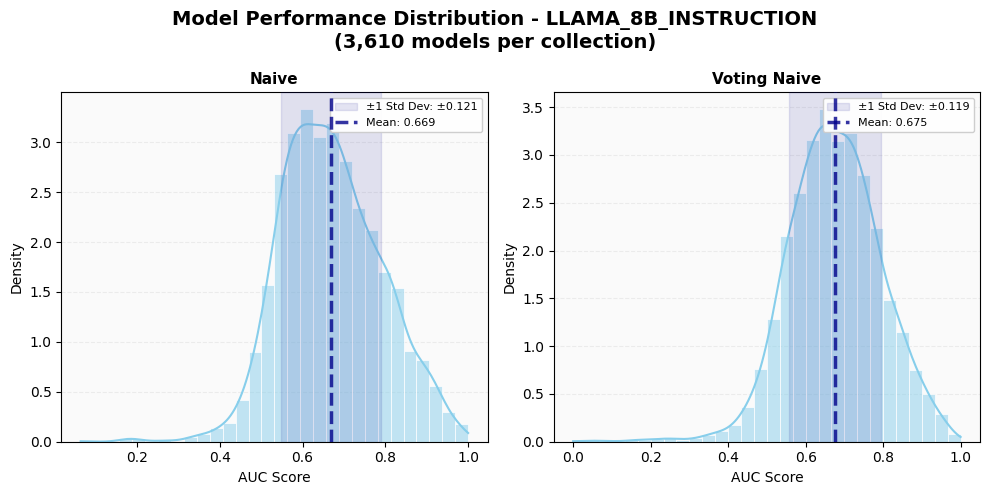


Completed processing llama_8b_instruction

COMPLETED: Processed 1 folders


In [8]:
folder_name = "llama_8b_instruction"

collections_data_llama8b_instruction = load_collections_for_folder(folder_name, BASE_PATH)

if collections_data_llama8b_instruction:
    trained_models_llama8b_instruction = train_all_collections_in_folder(folder_name, collections_data_llama8b_instruction, num_models=3610)
    print(f"\n{'='*60}\nSaving weights for {folder_name}\n{'='*60}")
    saved_weights_llama8b_instruction = save_all_weights_for_folder(folder_name, trained_models_llama8b_instruction, BASE_PATH)
    summaries_llama8b_instruction = create_summaries_for_folder(folder_name, trained_models_llama8b_instruction)
    save_results_for_folder(folder_name, trained_models_llama8b_instruction, summaries_llama8b_instruction, BASE_PATH)
    all_results_by_folder[folder_name] = {
        "collections_data": collections_data_llama8b_instruction,
        "trained_models": trained_models_llama8b_instruction,
        "saved_weights": saved_weights_llama8b_instruction,
        "summaries": summaries_llama8b_instruction
    }
    plot_folder_performance(folder_name, trained_models_llama8b_instruction)
    print(f"\nCompleted processing {folder_name}")
    gc.collect()
else:
    print(f"Failed to load collections for {folder_name}")

print(f"\n{'='*70}\nCOMPLETED: Processed {len(all_results_by_folder)} folders\n{'='*70}")
del collections_data_llama8b_instruction, trained_models_llama8b_instruction, saved_weights_llama8b_instruction, summaries_llama8b_instruction


Loading collections from: llama_8b_extraction

Loading naive...


Could not memory_map compressed IPC file, defaulting to normal read. Toggle off 'memory_map' to silence this warning.
Could not memory_map compressed IPC file, defaulting to normal read. Toggle off 'memory_map' to silence this warning.


  Train shape: (6769670, 7), Test shape: (676571, 7) (filtered eval nulls: train 450330, test 45429)

Loading voting_naive...


Could not memory_map compressed IPC file, defaulting to normal read. Toggle off 'memory_map' to silence this warning.
Could not memory_map compressed IPC file, defaulting to normal read. Toggle off 'memory_map' to silence this warning.


  Train shape: (7220000, 7), Test shape: (722000, 7) (filtered eval nulls: train 0, test 0)

Training 3610 models for naive (Binary Classification)
Best params file not found for naive at hyperparameter_tuning/llama_8b_extraction/best_params_gridsearch_naive.json. Skipping hyperparameter tuning.


Training naive: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 3610/3610 [01:05<00:00, 54.75it/s]


  Total errors: 0/3610

Training 3610 models for voting_naive (Binary Classification)
Best params file not found for voting_naive at hyperparameter_tuning/llama_8b_extraction/best_params_gridsearch_voting_naive.json. Skipping hyperparameter tuning.


Training voting_naive: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 3610/3610 [00:59<00:00, 60.56it/s]


  Total errors: 0/3610

Saving weights for llama_8b_extraction

  Saving naive: weights torch.Size([3610, 100]), bias torch.Size([3610])
    Saved to: weights/llama_8b_extraction/naive
    Saved to: runs/llama_8b_extraction/datamodels/models/naive

  Saving voting_naive: weights torch.Size([3610, 100]), bias torch.Size([3610])
    Saved to: weights/llama_8b_extraction/voting_naive
    Saved to: runs/llama_8b_extraction/datamodels/models/voting_naive

Evaluation Summary for llama_8b_extraction

naive:
  num_models: 3610
  successful_models: 3609
  mean_score: 0.6517
  std_score: 0.0996
  min_score: 0.1997
  max_score: 0.9452

voting_naive:
  num_models: 3610
  successful_models: 3609
  mean_score: 0.6641
  std_score: 0.1004
  min_score: 0.1206
  max_score: 0.9522
Saved results for llama_8b_extraction to aggregation_results/llama_8b_extraction_results.json


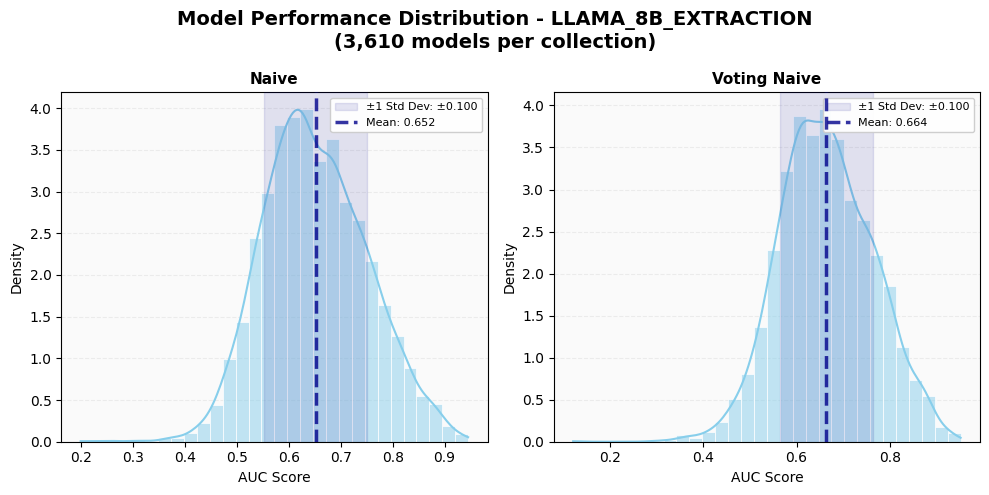


Completed processing llama_8b_extraction

COMPLETED: Processed 2 folders


In [9]:
folder_name = "llama_8b_extraction"

collections_data_llama8b_extraction = load_collections_for_folder(folder_name, BASE_PATH)

if collections_data_llama8b_extraction:
    trained_models_llama8b_extraction = train_all_collections_in_folder(folder_name, collections_data_llama8b_extraction, num_models=3610)
    print(f"\n{'='*60}\nSaving weights for {folder_name}\n{'='*60}")
    saved_weights_llama8b_extraction = save_all_weights_for_folder(folder_name, trained_models_llama8b_extraction, BASE_PATH)
    summaries_llama8b_extraction = create_summaries_for_folder(folder_name, trained_models_llama8b_extraction)
    save_results_for_folder(folder_name, trained_models_llama8b_extraction, summaries_llama8b_extraction, BASE_PATH)
    all_results_by_folder[folder_name] = {
        "collections_data": collections_data_llama8b_extraction,
        "trained_models": trained_models_llama8b_extraction,
        "saved_weights": saved_weights_llama8b_extraction,
        "summaries": summaries_llama8b_extraction
    }
    plot_folder_performance(folder_name, trained_models_llama8b_extraction)
    print(f"\nCompleted processing {folder_name}")
    gc.collect()
else:
    print(f"Failed to load collections for {folder_name}")

print(f"\n{'='*70}\nCOMPLETED: Processed {len(all_results_by_folder)} folders\n{'='*70}")
del collections_data_llama8b_extraction, trained_models_llama8b_extraction, saved_weights_llama8b_extraction, summaries_llama8b_extraction

## Aggregated Visualization: All Models Combined

Create a comprehensive visualization combining results from all four model categories.

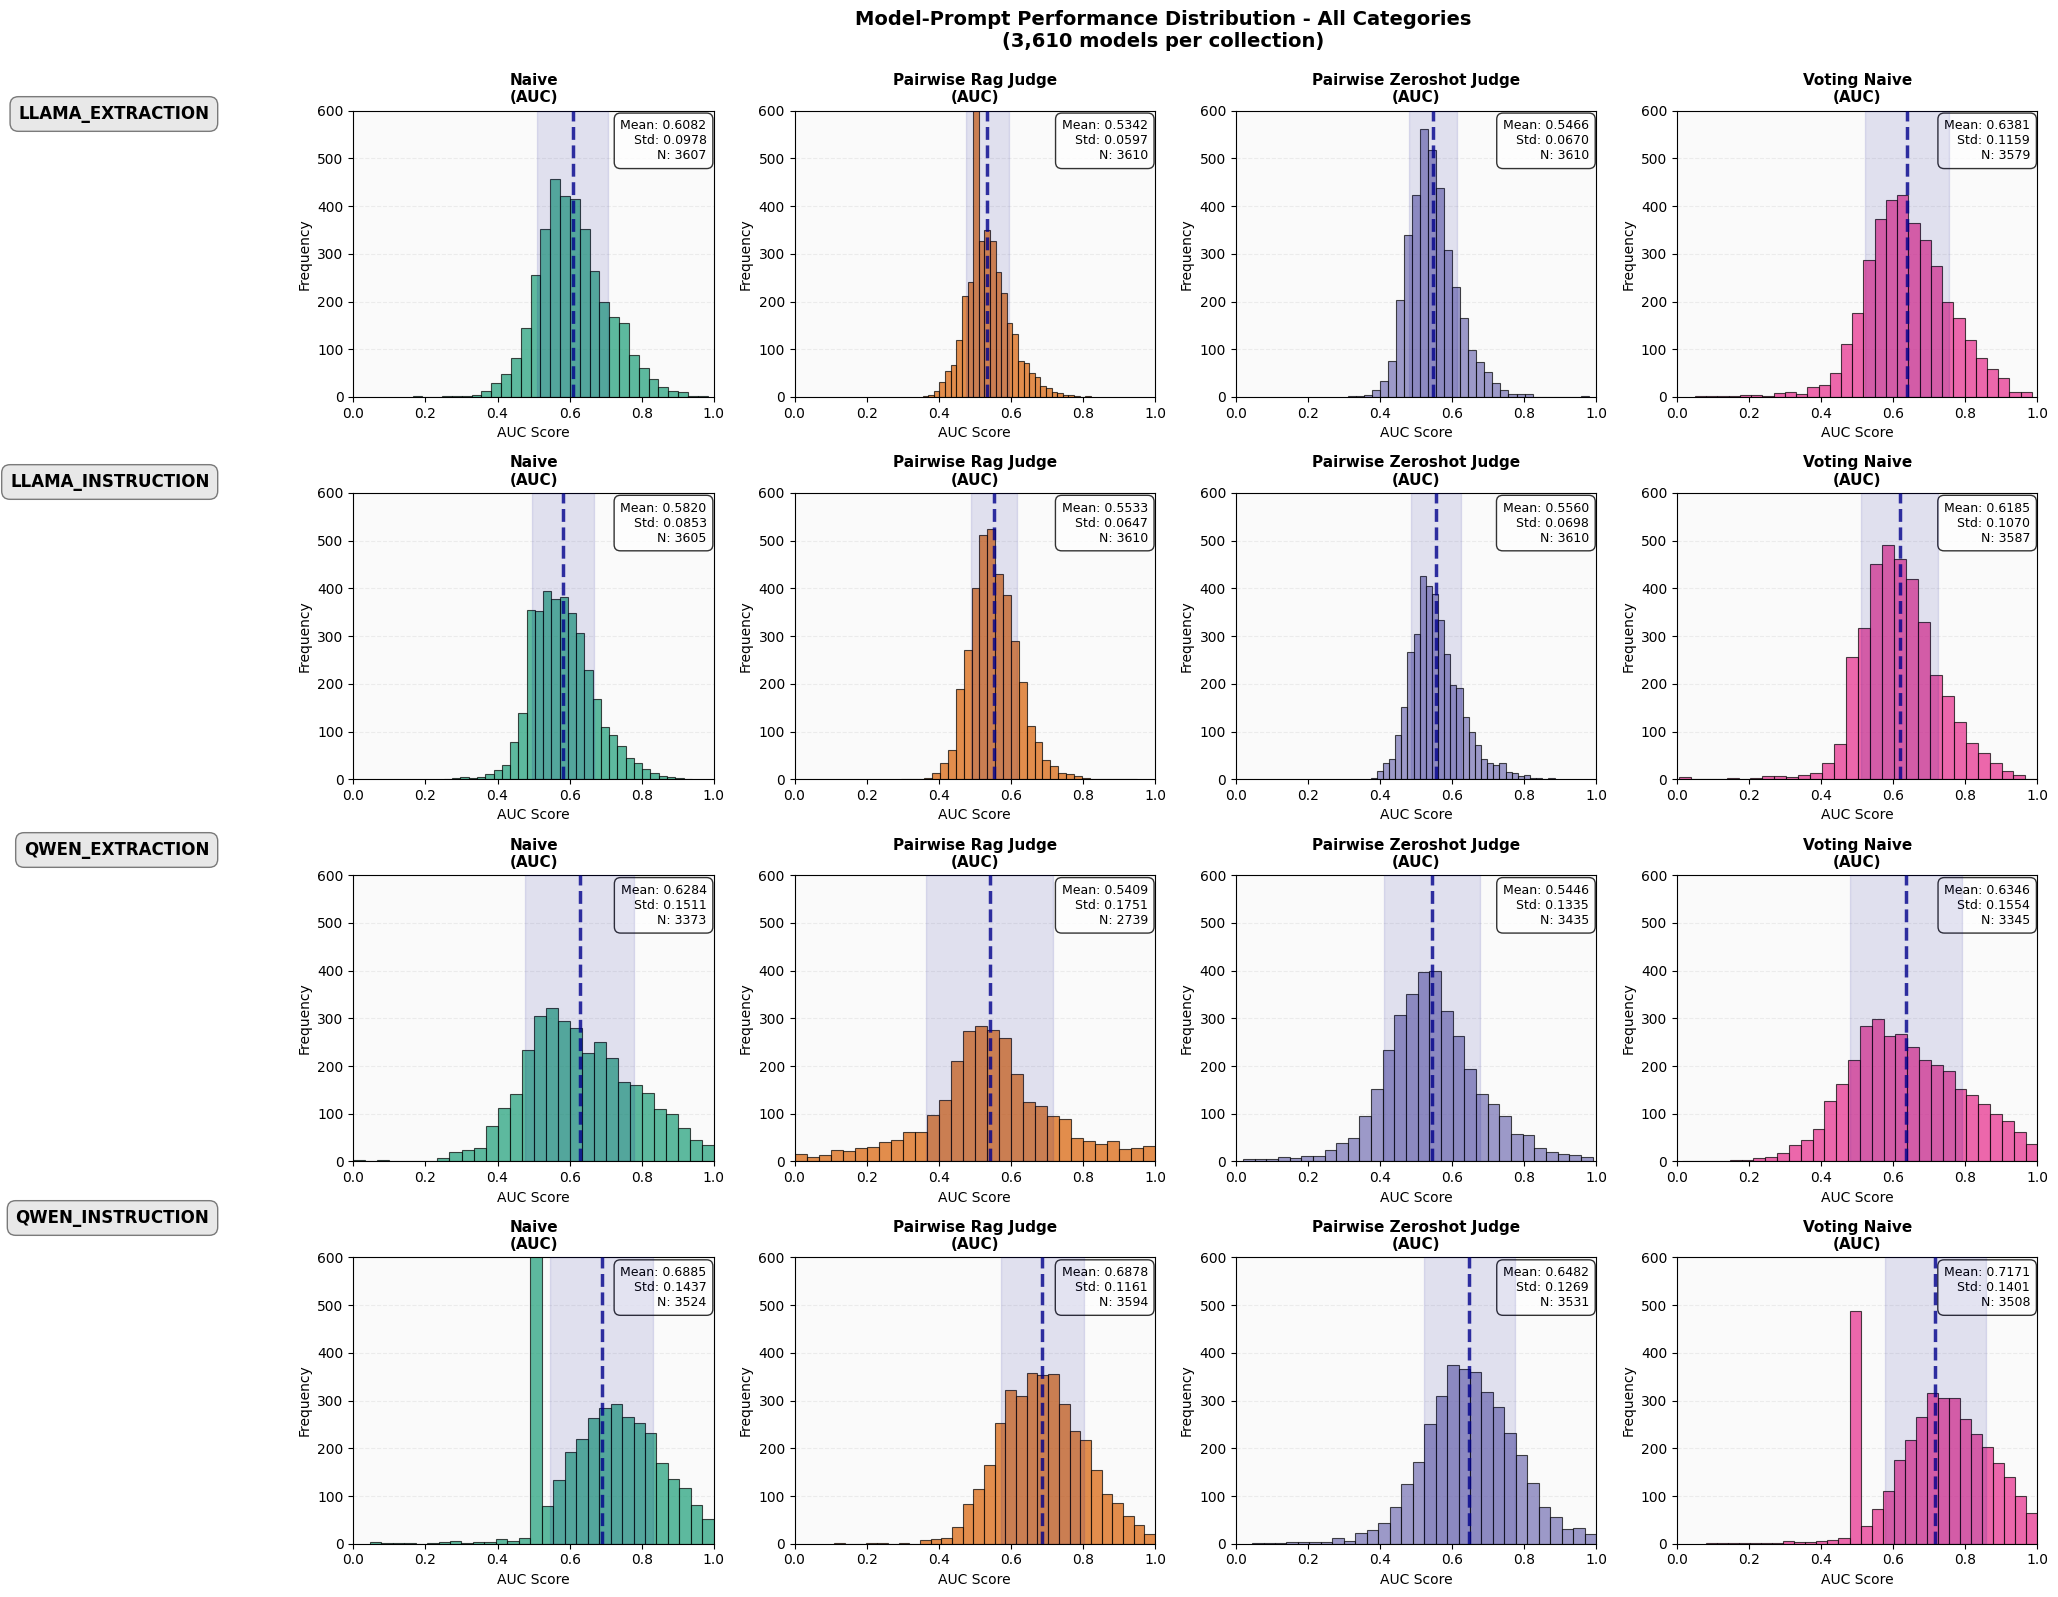


Aggregated visualization complete!


In [9]:
aggregated_results = load_all_results(BASE_PATH)

if aggregated_results:
    # Color mapping for each collection type
    collection_colors = {
        "naive": "#1b9e77",                # Green
        "pairwise_rag_judge": "#d95f02",   # Orange
        "pairwise_zeroshot_judge": "#7570b3", # Purple
        "voting_naive": "#e7298a"           # Light Red
    }
    
    folder_mapping = {
        "llama": "LLAMA_EXTRACTION",
        "llama_default": "LLAMA_INSTRUCTION",
        "qwen": "QWEN_EXTRACTION",
        "qwen_default": "QWEN_INSTRUCTION"
    }
    folder_order = ["llama", "llama_default", "qwen", "qwen_default"]
    
    fig, axes = plt.subplots(4, 4, figsize=(18, 16))
    
    for row_idx, folder_name in enumerate(folder_order):
        if folder_name not in aggregated_results:
            print(f"Warning: {folder_name} not found in results")
            continue
        
        folder_data = aggregated_results[folder_name]
        evaluations = folder_data["evaluations"]
        display_name = folder_mapping[folder_name]
        
        for col_idx, collection_name in enumerate(MODEL_SUBFOLDERS):
            ax = axes[row_idx, col_idx]
            
            if collection_name in evaluations:
                scores = evaluations[collection_name]["scores"]
                color = collection_colors.get(collection_name, "#87CEEB")
                mean = evaluations[collection_name]["mean"]
                std = evaluations[collection_name]["std"]
                n_samples = len(scores)
                
                ax.hist(scores, bins=30, alpha=0.7, color=color, edgecolor='black', linewidth=0.8)
                collection_display = collection_name.replace("_", " ").title()
                ax.set_title(f"{collection_display}\n(AUC)", fontsize=11, fontweight='bold')
                ax.set_xlabel("AUC Score", fontsize=10)
                ax.set_ylabel("Frequency", fontsize=10)
                ax.set_xlim(0, 1)
                ax.set_ylim(0, 600)
                ax.grid(axis='y', alpha=0.2, linestyle='--')
                ax.set_axisbelow(True)
                ax.set_facecolor('#fafafa')
                stats_text = f"Mean: {mean:.4f}\nStd: {std:.4f}\nN: {n_samples}"
                ax.text(0.98, 0.97, stats_text, transform=ax.transAxes,
                       fontsize=9, verticalalignment='top', horizontalalignment='right',
                       bbox=dict(boxstyle='round', facecolor='white', alpha=0.8, pad=0.5))
                ax.axvline(mean, color='darkblue', linestyle='--', linewidth=2.5, alpha=0.8, zorder=10)
                ax.axvspan(mean - std, mean + std, color='darkblue', alpha=0.1, zorder=5)
            else:
                ax.axis('off')
        
        fig.text(-0.03, 0.93 - (row_idx * 0.23), display_name, 
                va='center', ha='right', fontsize=12, fontweight='bold',
                bbox=dict(boxstyle='round', facecolor='lightgray', alpha=0.5, pad=0.5))
    
    fig.suptitle('Model-Prompt Performance Distribution - All Categories\n(3,610 models per collection)', 
                 fontsize=14, fontweight='bold', y=0.995)
    
    plt.tight_layout()
    plt.subplots_adjust(left=0.05)
    plt.show()
    plt.close()
    
    print(f"\n{'='*70}\nAggregated visualization complete!\n{'='*70}")
else:
    print("Failed to load aggregated results")